<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Decision_Tree/DecisionTree_Gini_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 48 (delta 3), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (48/48), 162.58 MiB | 9.54 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (25/25), done.
Filtering content: 100% (12/12), 851.90 MiB | 32.03 MiB/s, done.
/content/PRMLProject


In [ ]:
import numpy as np
from skimage.feature import hog
from tqdm import tqdm
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data

In [ ]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

In [ ]:
X_train = [train_RawData.reshape(-1,3072),train_HoGData,train_PcaData,train_HoG_PcaData,train_Pca_HoGData]
y_train = train_labels
X_test = [test_RawData.reshape(-1,3072),test_HoGData,test_PcaData,test_HoG_PcaData,test_Pca_HoGData]
y_test = test_labels

In [ ]:
print('Number of Training Samples ---> ',y_train.shape[0])
print('Dimensions of a Sample of RawData ---> ', X_train[0].shape[1])
print('Dimensions of a Sample of HoGData ---> ',X_train[1].shape[1])
print('Dimensions of a Sample of PCAData ---> ',X_train[2].shape[1])
print('Dimensions of a Sample of HoG_PCAData ---> ',X_train[3].shape[1])
print('Dimensions of a Sample of PCA_HoGData ---> ',X_train[4].shape[1])

Number of Training Samples --->  50000
Dimensions of a Sample of RawData --->  3072
Dimensions of a Sample of HoGData --->  324
Dimensions of a Sample of PCAData --->  658
Dimensions of a Sample of HoG_PCAData --->  170
Dimensions of a Sample of PCA_HoGData --->  324


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from tqdm import tqdm

def trainDecisionTree(X_train, y_train, max_depth, criterion):
    '''
      Fits a decision tree for the given data and impurity
    '''
    tree = DecisionTreeClassifier(criterion = criterion, max_depth=max_depth)
    tree.fit(X_train, y_train)
    return tree

def findMaxDepth(X_train, y_train, criterion):
    '''
      Finds the max_depth of the tree, that is the depth for which the tree is
      fully grown(train accuracy approaches 100%)
    '''
    print('Finding the max depth')
    max_depth = 100
    train_accuracies = []
    for depth in tqdm(range(1, max_depth)):
        tree = trainDecisionTree(X_train, y_train, depth, criterion)
        train_accuracy = tree.score(X_train, y_train)
        train_accuracies.append(train_accuracy)
        if train_accuracy >= 0.99:
            return depth, train_accuracies
    return max_depth, train_accuracies

def findOptimalDepth(X_train, y_train, criterion):
    '''
      Finds the optimal depth of the tree using GridSearchCV,
       to avoid overfitting
    '''
    max_depth, train_accuracies = findMaxDepth(X_train, y_train, criterion)
    param_grid = {'max_depth': list(range(1, max_depth + 1))}

    print('Finding Optimal depth')
    # Using 5 Fold Cross Validation
    grid_search = GridSearchCV(DecisionTreeClassifier(criterion=criterion), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search.best_params_['max_depth'], grid_search.best_score_, grid_search.cv_results_['mean_test_score'], train_accuracies,max_depth

def plot_accuracies_vs_depths(depths, train_accuracies, validation_accuracies, title_string,optimal_depth):
    '''
        Helping function to plot accuracy vs depth plots
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_accuracies, marker='o', linestyle='--', color='r', label='Training Accuracy')
    plt.plot(depths, validation_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
    plt.plot(optimal_depth, validation_accuracies[optimal_depth-1], marker='s', markersize=8, color='black')
    plt.plot(optimal_depth, train_accuracies[optimal_depth-1], marker='s', markersize=8, color='black')


    plt.xlabel('Depth')
    plt.ylabel('Accuracy')
    plt.title('Depth vs Accuracy ' + title_string)
    plt.xticks(depths)
    plt.legend()
    plt.show()

def DecisionTree(X_train, y_train, criterion):

    optimal_depth, best_score, validation_accuracies, train_accuracies, MaxDepth = findOptimalDepth(X_train, y_train, criterion)

    optimal_tree = trainDecisionTree(X_train, y_train, optimal_depth, criterion)

    return optimal_tree, optimal_depth, best_score, validation_accuracies, train_accuracies, MaxDepth

def predict(tree, X_test) :

    return tree.predict(X_test)

def testAccuracy(LabelsPrediction, LabelsActual) :

    return np.sum(LabelsPrediction == LabelsActual ) / len(LabelsActual)

In [ ]:
OptimalTree_HoG_PCA, OptimalDepth_HoG_PCA, BestScore_HoG_PCA, Validation_HoG_PCA, Train_HoG_PCA, MaxDepth_HoG_PCA = DecisionTree(X_train[3], y_train, 'gini')

Finding the max depth


 23%|██▎       | 23/99 [06:58<23:01, 18.18s/it]

Finding Optimal depth


In [ ]:
OptimalTree_HoG, OptimalDepth_HoG, BestScore_HoG, Validation_HoG, Train_HoG, MaxDepth_HoG = DecisionTree(X_train[1], y_train, 'gini')

Finding the max depth


 24%|██▍       | 24/99 [14:18<44:41, 35.75s/it]

Finding Optimal depth


In [ ]:
OptimalTree_PCA_HoG, OptimalDepth_PCA_HoG, BestScore_PCA_HoG, Validation_PCA_HoG, Train_PCA_HoG, MaxDepth_PCA_HoG = DecisionTree(X_train[4], y_train, 'gini')

Finding the max depth


 23%|██▎       | 23/99 [13:37<45:00, 35.53s/it]

Finding Optimal depth


In [ ]:
OptimalTree_PCA, OptimalDepth_PCA, BestScore_PCA, Validation_PCA, Train_PCA, MaxDepth_PCA = DecisionTree(X_train[2], y_train, 'gini')

Finding the max depth


 26%|██▋       | 26/99 [33:20<1:33:37, 76.95s/it] 

Finding Optimal depth


In [55]:
print('OptimalDepth of Tree for HoG_PCA -->',OptimalDepth_HoG_PCA)
print('OptimalDepth of Tree for HoG -->',OptimalDepth_HoG)
print('OptimalDepth of Tree for PCA_HoG -->',OptimalDepth_PCA_HoG)
print('OptimalDepth of Tree for PCA -->',OptimalDepth_PCA)

OptimalDepth of Tree for HoG_PCA --> 9
OptimalDepth of Tree for HoG --> 11
OptimalDepth of Tree for PCA_HoG --> 10
OptimalDepth of Tree for PCA --> 9


In [56]:
print('Best Validation accuracy for HoG_PCA -->',BestScore_HoG_PCA)
print('Best Validation accuracy for HoG -->',BestScore_HoG)
print('Best Validation accuracy for PCA_HoG -->',BestScore_PCA_HoG)
print('Best Validation accuracy for PCA -->',BestScore_PCA)

Best Validation accuracy for HoG_PCA --> 0.35892
Best Validation accuracy for HoG --> 0.31223999999999996
Best Validation accuracy for PCA_HoG --> 0.27637999999999996
Best Validation accuracy for PCA --> 0.30441999999999997


In [54]:
print('MaxDepth of Tree for HoG_PCA -->',MaxDepth_HoG_PCA)
print('MaxDepth of Tree for HoG -->',MaxDepth_HoG)
print('MaxDepth of Tree for PCA_HoG -->',MaxDepth_PCA_HoG)
print('MaxDepth of Tree for PCA -->',MaxDepth_PCA)

MaxDepth of Tree for HoG_PCA --> 24
MaxDepth of Tree for HoG --> 25
MaxDepth of Tree for PCA_HoG --> 24
MaxDepth of Tree for PCA --> 27


In [50]:
print('Average Validation accuracies for different depths using HoG_PCA --->',Validation_HoG_PCA)
print('Average Validation accuracies for different depths using HoG --->',Validation_HoG)
print('Average Validation accuracies for different depths using PCA_HoG --->',Validation_PCA_HoG)
print('Average Validation accuracies for different depths using PCA --->',Validation_PCA)

Average Validation accuracies for different depths using HoG_PCA ---> [0.1727  0.21668 0.26034 0.28992 0.31116 0.32316 0.33902 0.3529  0.35892
 0.3554  0.34808 0.33932 0.33146 0.32294 0.31266 0.3056  0.30116 0.29884
 0.2977  0.2952  0.2936  0.29306 0.2918  0.29192]
Average Validation accuracies for different depths using HoG ---> [0.1527  0.17798 0.21468 0.24308 0.25962 0.27662 0.29458 0.30312 0.30946
 0.31222 0.31224 0.30936 0.30232 0.29782 0.29388 0.29048 0.28676 0.28134
 0.28108 0.27956 0.28064 0.27874 0.27924 0.27764 0.2764 ]
Average Validation accuracies for different depths using PCA_HoG ---> [0.1505  0.16926 0.20616 0.22068 0.241   0.2535  0.26282 0.26914 0.27462
 0.27638 0.274   0.27486 0.27082 0.26398 0.26096 0.25442 0.25282 0.24902
 0.24646 0.24698 0.24514 0.24414 0.24744 0.24552]
Average Validation accuracies for different depths using PCA ---> [0.14724 0.19426 0.21994 0.2338  0.25294 0.2684  0.2908  0.29792 0.30442
 0.3     0.29652 0.28822 0.27938 0.27212 0.26482 0.26162 0.

In [49]:
print('Training accuracies for different depths using HoG_PCA --->',Train_HoG_PCA)
print('Training accuracies for different depths using HoG --->',Train_HoG)
print('Training accuracies for different depths using PCA_HoG --->',Train_PCA_HoG)
print('Training accuracies for different depths using PCA --->',Train_PCA)

Training accuracies for different depths using HoG_PCA ---> [0.17278, 0.21788, 0.26184, 0.29328, 0.31736, 0.33734, 0.36592, 0.39426, 0.42506, 0.46338, 0.51122, 0.56686, 0.6302, 0.69418, 0.75518, 0.81042, 0.85974, 0.89912, 0.931, 0.95504, 0.97028, 0.98178, 0.98908, 0.99346]
Training accuracies for different depths using HoG ---> [0.1533, 0.17802, 0.21098, 0.2455, 0.26212, 0.29596, 0.32228, 0.34192, 0.37528, 0.41034, 0.45476, 0.50646, 0.56714, 0.62936, 0.69386, 0.75606, 0.81246, 0.8616, 0.90172, 0.9329, 0.95546, 0.97126, 0.98222, 0.9888, 0.993]
Training accuracies for different depths using PCA_HoG ---> [0.15144, 0.17, 0.20872, 0.22946, 0.25524, 0.26828, 0.29464, 0.31916, 0.34706, 0.3822, 0.43014, 0.48616, 0.55014, 0.61952, 0.68748, 0.75466, 0.81532, 0.86694, 0.90874, 0.94038, 0.96264, 0.97842, 0.98804, 0.99362]
Training accuracies for different depths using PCA ---> [0.1475, 0.19534, 0.22078, 0.23676, 0.25728, 0.27922, 0.31404, 0.33932, 0.37176, 0.40542, 0.44814, 0.49704, 0.55278, 0.611

In [ ]:
Predictions_HoG_PCA = predict(OptimalTree_HoG_PCA, X_test[3])
Predictions_HoG = predict(OptimalTree_HoG, X_test[1])
Predictions_PCA_HoG = predict(OptimalTree_PCA_HoG, X_test[4])
Predictions_PCA = predict(OptimalTree_PCA, X_test[2])

In [ ]:
testAccuracy_HoG_PCA = testAccuracy(Predictions_HoG_PCA, y_test)
testAccuracy_HoG = testAccuracy(Predictions_HoG, y_test)
testAccuracy_PCA_HoG = testAccuracy(Predictions_PCA_HoG, y_test)
testAccuracy_PCA = testAccuracy(Predictions_PCA, y_test)

In [48]:
print('Testing accuracy for HoG_PCA --->',testAccuracy_HoG_PCA)
print('Testing accuracy for HoG --->',testAccuracy_HoG)
print('Testing accuracy for PCA_HoG --->',testAccuracy_PCA_HoG)
print('Testing accuracy for PCA --->',testAccuracy_PCA)

Testing accuracy for HoG_PCA ---> 0.3645
Testing accuracy for HoG ---> 0.3139
Testing accuracy for PCA_HoG ---> 0.2835
Testing accuracy for PCA ---> 0.3127


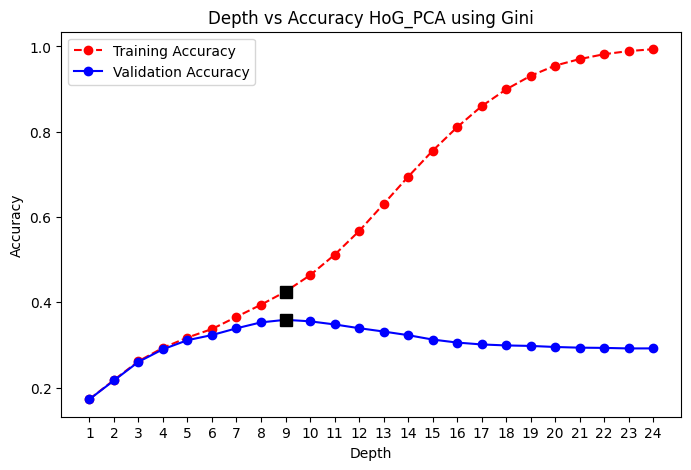

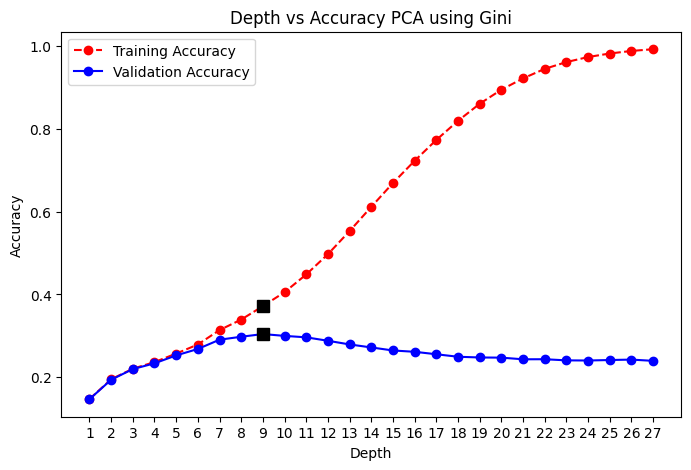

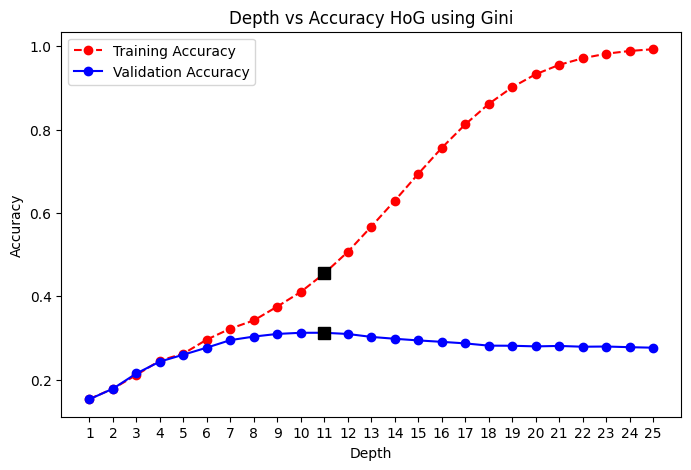

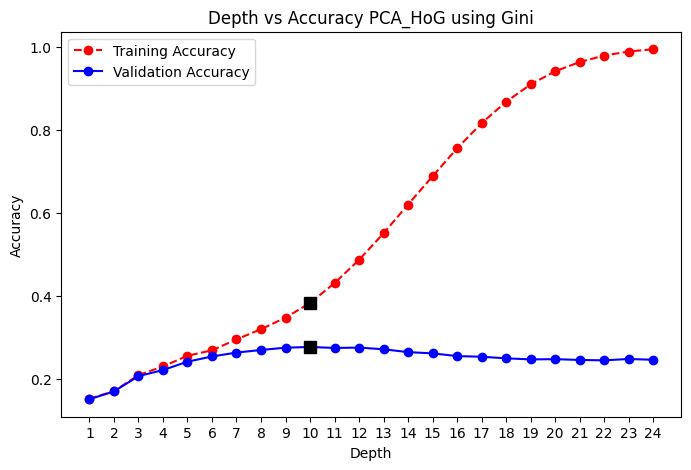

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_HoG_PCA+1), Train_HoG_PCA, Validation_HoG_PCA, 'HoG_PCA using Gini',OptimalDepth_HoG_PCA)
plot_accuracies_vs_depths(range(1, MaxDepth_PCA+1), Train_PCA, Validation_PCA, 'PCA using Gini',OptimalDepth_PCA)
plot_accuracies_vs_depths(range(1, MaxDepth_HoG+1), Train_HoG, Validation_HoG, 'HoG using Gini',OptimalDepth_HoG)
plot_accuracies_vs_depths(range(1, MaxDepth_PCA_HoG+1), Train_PCA_HoG, Validation_PCA_HoG, 'PCA_HoG using Gini',OptimalDepth_PCA_HoG)

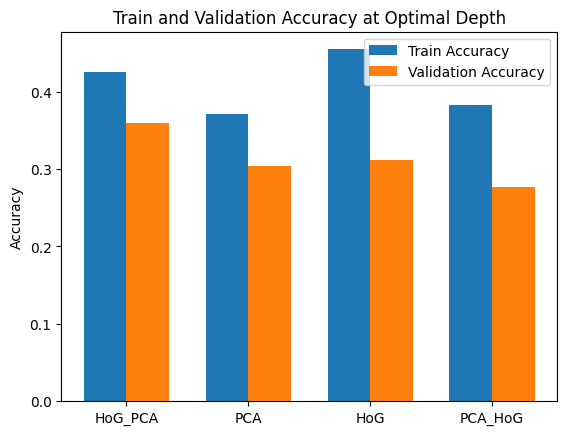

In [45]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['HoG_PCA', 'PCA', 'HoG', 'PCA_HoG']
optimal_depths = [OptimalDepth_HoG_PCA, OptimalDepth_PCA, OptimalDepth_HoG, OptimalDepth_PCA_HoG]
train_accuracies = [Train_HoG_PCA[OptimalDepth_HoG_PCA - 1], Train_PCA[OptimalDepth_PCA - 1], Train_HoG[OptimalDepth_HoG - 1], Train_PCA_HoG[OptimalDepth_PCA_HoG - 1]]
validation_accuracies = [Validation_HoG_PCA[OptimalDepth_HoG_PCA - 1], Validation_PCA[OptimalDepth_PCA - 1], Validation_HoG[OptimalDepth_HoG - 1], Validation_PCA_HoG[OptimalDepth_PCA_HoG - 1]]

bar_width = 0.35

fig, ax = plt.subplots()
bar1 = ax.bar(np.arange(len(datasets)), train_accuracies, bar_width, label='Train Accuracy')
bar2 = ax.bar(np.arange(len(datasets)) + bar_width, validation_accuracies, bar_width, label='Validation Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Train and Validation Accuracy at Optimal Depth')
ax.set_xticks(np.arange(len(datasets)) + bar_width / 2)
ax.set_xticklabels(datasets)
ax.legend()

plt.show()

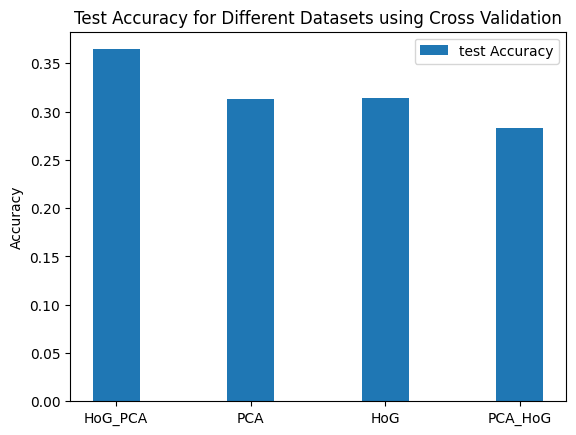

In [60]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['HoG_PCA', 'PCA', 'HoG', 'PCA_HoG']
testAccuracies = [testAccuracy_HoG_PCA, testAccuracy_PCA, testAccuracy_HoG, testAccuracy_PCA_HoG]
bar_width = 0.35

fig, ax = plt.subplots()
bar2 = ax.bar(np.arange(len(datasets)), testAccuracies, bar_width, label='test Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Test Accuracy for Different Datasets using Cross Validation')
ax.set_xticks(np.arange(len(datasets)))
ax.set_xticklabels(datasets)
ax.legend()

plt.show()